# Cross Pair Correlation Functions (cross-netPCF)

The cross-pair correlation function (cross-PCF) extends the pair correlation function to quantify spatial relationships between two distinct point populations. Rather than measuring the spatial organisation of a single population, the cross-PCF estimates how one population is distributed relative to another across multiple length scales.

Suppose we have two node populations, `A` and `B`, defined on the same spatial network. The cross-PCF is computed by centring the estimation kernel on each node in population `A` and estimating the local density of nodes belonging to population `B` as a function of network distance. These observed densities are then compared with the expected densities under a statistical null model for population `B`, typically complete spatial randomness (CSR) when no prior distribution is available.

As with the network pair correlation function (`netPCF`), the interpretation under CSR is straightforward:

* Values greater than **1** indicate clustering (co-localisation) of population `B` around population `A` at that network distance.
* Values less than **1** indicate spatial exclusion or inhibition.
* Values close to **1** indicate behaviour consistent with spatial randomness.

This methodology was extended to spatial networks in:

**Moore et al. (2026). *netPCF: Geometry-aware Pair Correlation Functions for Spatial Biology*.** DOI: ...

In this tutorial, we'll demonstrate the practical use of the network cross-pair correlation function using `cross_pair_correlation_function()`. For the mathematical details of the estimator, please refer to the reference paper.

We'll begin by loading the same spiral dataset used in the `netPCF` tutorial together with its associated categorical node labels.


(<Figure size 960x720 with 2 Axes>, <Axes: >)

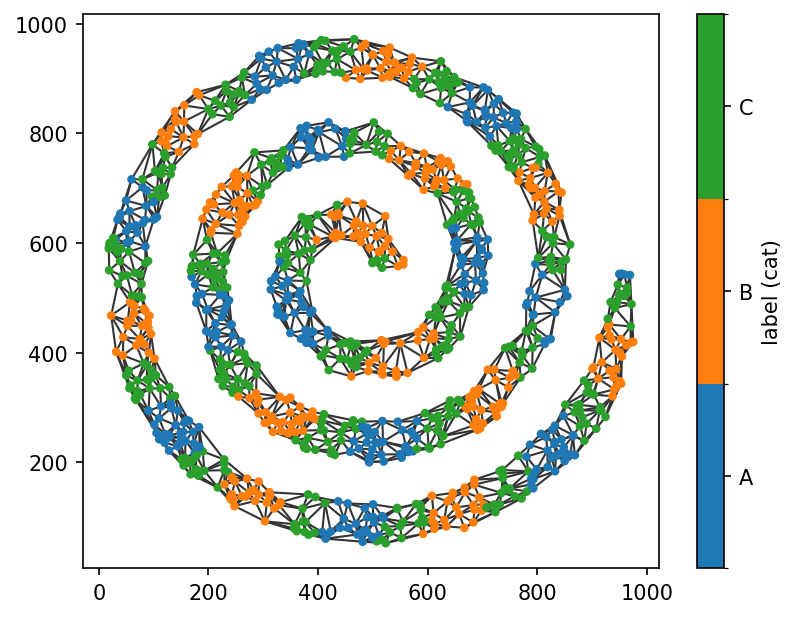

In [1]:
import spacenet as sn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# load in the example dataset 'sprial'
spiral_data = sn.datasets.load_dataset('spiral')

# extract the point data and labels
points = np.array([spiral_data['x'],spiral_data['y']]).T
cat_labels = spiral_data['Marker (categorical)']

# generate a spatial network and add the labels
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=75)
sn.utils.add_node_labels(spatial_net,labels=cat_labels,node_label_name='label (cat)')

# plot the spatial network with nodes colored by the demo labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='label (cat)')

To illustrate the cross-network pair correlation function, we'll estimate the spatial relationship between the nodes labelled `A` and those labelled `B`. The first step is to identify the node IDs corresponding to each population.

These node subsets can be defined in any way you choose. Since the populations are already stored as node labels, we can conveniently retrieve the required node IDs using SpaceNet's querying functionality.

In [2]:
# get the node IDs of all nodes with label A and B
nodes_A = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value='A')
nodes_B = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value='B')

Now that we have identified the node IDs for the `A` and `B` populations, we can pass them to `cross_pair_correlation_function()` together with the parameters that define the spatial kernel and the range of network distances over which the pair correlation function is evaluated.


In [3]:
# estimate netPCF over all points with label A 
radii_a_b,pcf_values_a_b,con_inter_a_b = sn.point_patterns.cross_pair_correlation_function(spatial_net,
                                                                                     nodes_a=nodes_A,
                                                                                     nodes_b=nodes_B,
                                                                                     spatial_kernel_bandwidth=50,
                                                                                     r_max=500,
                                                                                     r_step=10,
                                                                                     return_confidence_interval=True)

Computing node-node distances...


Computing contributions: 100%|██████████| 326/326 [00:02<00:00, 128.31contributions/s]


Computing confidence intervals via spatial bootstrap...


We've now computed the cross-network pair correlation function together with its associated 95% confidence intervals. Let's visualise the estimated correlation function and its confidence bounds, as in the previous tutorial.


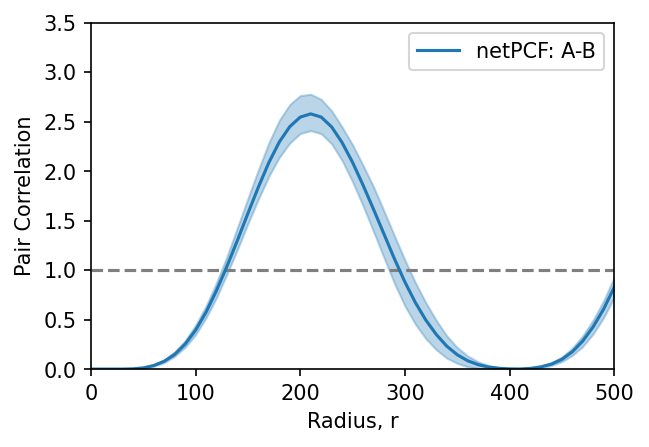

In [4]:
# plot the PCF curves estimated over the points A and over all nodes for comparison
fig,ax=plt.subplots(figsize=(4.5,3))
ax.axhline(1,linestyle='--',color='tab:grey')

ax.fill_between(radii_a_b,con_inter_a_b[0],con_inter_a_b[1],alpha=0.3,color='tab:blue')
ax.plot(radii_a_b,pcf_values_a_b,color='tab:blue',label='netPCF: A-B')

ax.set_ylim(0,3.5)
ax.set_xlim(0,500)
ax.set_xlabel('Radius, r')
ax.set_ylabel('Pair Correlation')
ax.legend()

Recall that the dashed horizontal line at **1** corresponds to the expectation under complete spatial randomness (CSR). Values below **1** therefore indicate spatial exclusion, while values above **1** indicate co-localisation.

In this example, the cross-network pair correlation function indicates that `B`-labelled nodes are less likely than expected to occur within approximately 100 distance units of `A`-labelled nodes, followed by a pronounced peak in co-localisation at around 200 distance units. This oscillatory pattern then repeats at larger network distances.

This behaviour is consistent with the construction of the dataset. The `A` and `B` populations are arranged periodically along the spiral, with alternating clusters separated by approximately 200 distance units. The cross-network pair correlation function correctly captures this repeating spatial organisation.

The same approach can be applied to any pair of node populations. In the example below, we compute the cross-network pair correlation function for every combination of labels. Notice that the `C` population lies between the `A` and `B` populations, with clusters that are approximately half the width of the `A` and `B` clusters. This difference in spatial organisation is reflected in the corresponding pair correlation functions involving the `C` population.


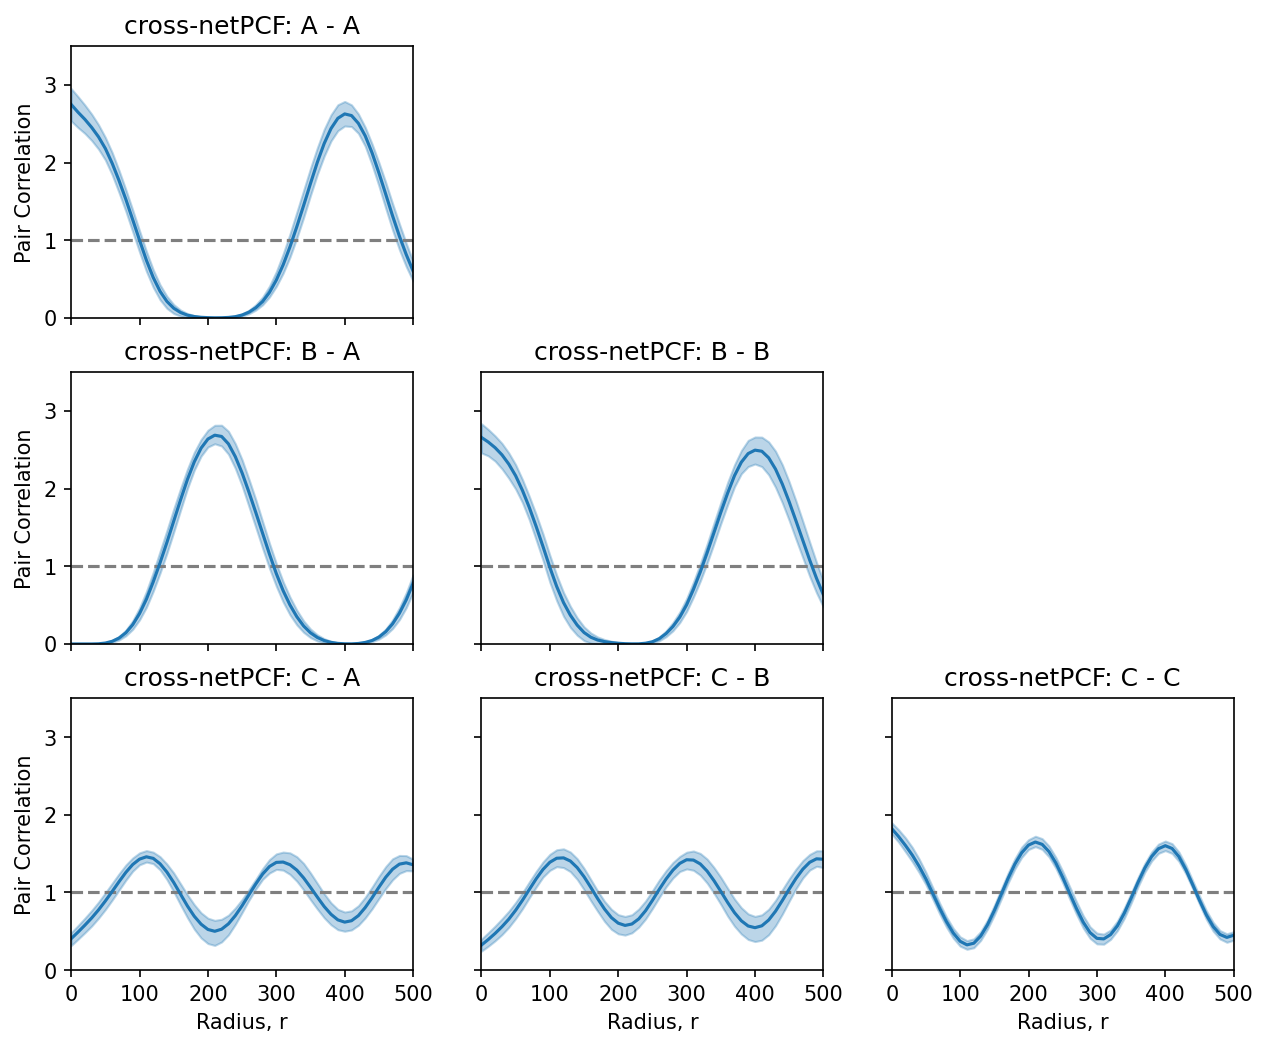

In [5]:
available_labels = ['A','B','C']

fig,ax=plt.subplots(len(available_labels),len(available_labels),figsize=(10,8),sharey=True,sharex=True)
for i,label_1 in enumerate(available_labels):
    for j, label_2 in enumerate(available_labels):
        
        if i>=j:
            
            # get the relevant node IDs
            nodes_1 = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value=label_1)
            nodes_2 = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value=label_2)
            
            # estimate cross-netPCF
            this_radii,these_pcf_values,this_con_inter = sn.point_patterns.cross_pair_correlation_function(spatial_net,
                                                                                                        nodes_a=nodes_1,
                                                                                                        nodes_b=nodes_2,
                                                                                                        spatial_kernel_bandwidth=50,
                                                                                                        r_max=500,
                                                                                                        r_step=10,
                                                                                                        return_confidence_interval=True,
                                                                                                        verbose=False)

            # plotting the outputs
            ax[i,j].axhline(1,linestyle='--',color='tab:grey')
            ax[i,j].fill_between(this_radii,this_con_inter[0],this_con_inter[1],alpha=0.3,color='tab:blue')
            ax[i,j].plot(this_radii,these_pcf_values,color='tab:blue')

            ax[i,j].set_ylim(0,3.5)
            ax[i,j].set_xlim(0,500)
            ax[i,j].set_title(f'cross-netPCF: {label_1} - {label_2}')
            
            if i==(len(available_labels)-1):
                ax[i,j].set_xlabel('Radius, r')
            if j==0:    
                ax[i,j].set_ylabel('Pair Correlation')
            
        else:
            ax[i,j].set_axis_off()
    